<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/Updated_code_on_K_means_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload the file:


Saving Retail_Store_Segmentation.csv to Retail_Store_Segmentation.csv
Data Shape: (5000, 10)


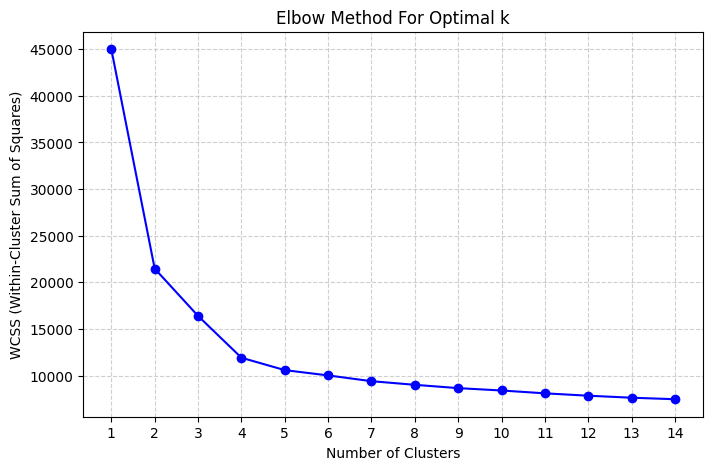

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load the Dataset
# If running locally, ensure 'Retail_Store_Segmentation.csv' is in your directory.
csv_filename = "Retail_Store_Segmentation.csv"

if not os.path.exists(csv_filename):
    try:
        from google.colab import files

        print("Please upload the file:")
        uploaded = files.upload()
    except ImportError:
        raise FileNotFoundError(
            f"'{csv_filename}' not found. Please place it in the working directory."
        )

df = pd.read_csv(csv_filename)

# 2. Inspect the data (Optional but good practice)
print(f"Data Shape: {df.shape}")

# 3. Feature Selection & Preprocessing
# Drop the identifier column 'Store_ID'
features = df.drop(columns=["Store_ID"])

# Optional Enhancement: If 'City_Tier' should be categorical rather than continuous:
# features = pd.get_dummies(features, columns=['City_Tier'], drop_first=True)

# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 5. Elbow Method using KMeans
wcss = []
cluster_range = range(1, 15)

for i in cluster_range:
    kmeans = KMeans(
        n_clusters=i,
        n_init=10,  # Explicitly set to avoid current/future warnings
        random_state=42,
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 6. Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, wcss, marker="o", linestyle="-", color="b")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method For Optimal k")
plt.xticks(cluster_range)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Based on your graph, 3 to 5 clusters is indeed the correct choice!

In [2]:
# 1. Initialize KMeans with your chosen number of clusters (e.g., 3, 4, or 5)
# Let's assume 4 clusters based on the elbow point.
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)

# 2. Fit the model and predict cluster IDs for each retail store
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. View the distribution of stores across your new clusters
print("Store counts per cluster:")
print(df['Cluster'].value_counts())

# 4. Check the characteristics of each cluster (Cluster Profiles)
cluster_profiles = df.groupby('Cluster').mean(numeric_only=True)
display(cluster_profiles)

Store counts per cluster:
Cluster
3    2002
0    1010
1     999
2     989
Name: count, dtype: int64


,City_Tier,Monthly_Customers,Monthly_Sales,Average_Basket_Value,Product_Categories,Staff_Count,Customer_Satisfaction,Return_Rate,Marketing_Spend
Cluster,,,,,,,,,
0,1.0,18315.479208,2.733587e+06,552.339604,25.329703,34.575248,77.236634,4.928257,6.530881e+05
1,3.0,2999.680681,4.887623e+05,247.711712,9.527528,12.078078,56.573574,10.103814,1.484196e+05
2,1.0,11547.491405,5.509215e+06,1659.770475,29.625885,41.447927,89.229525,2.930900,1.006954e+06
3,2.0,7762.260240,1.556686e+06,433.685315,15.299201,17.870629,71.039960,7.215190,5.511400e+05


--- Store Count Per Cluster ---
Cluster
3    2002
0    1010
1     999
2     989
Name: count, dtype: int64


--- Average Feature Values per Cluster ---


,City_Tier,Monthly_Customers,Monthly_Sales,Average_Basket_Value,Product_Categories,Staff_Count,Customer_Satisfaction,Return_Rate,Marketing_Spend
Cluster,,,,,,,,,
0,1.0,18315.479208,2.733587e+06,552.339604,25.329703,34.575248,77.236634,4.928257,6.530881e+05
1,3.0,2999.680681,4.887623e+05,247.711712,9.527528,12.078078,56.573574,10.103814,1.484196e+05
2,1.0,11547.491405,5.509215e+06,1659.770475,29.625885,41.447927,89.229525,2.930900,1.006954e+06
3,2.0,7762.260240,1.556686e+06,433.685315,15.299201,17.870629,71.039960,7.215190,5.511400e+05


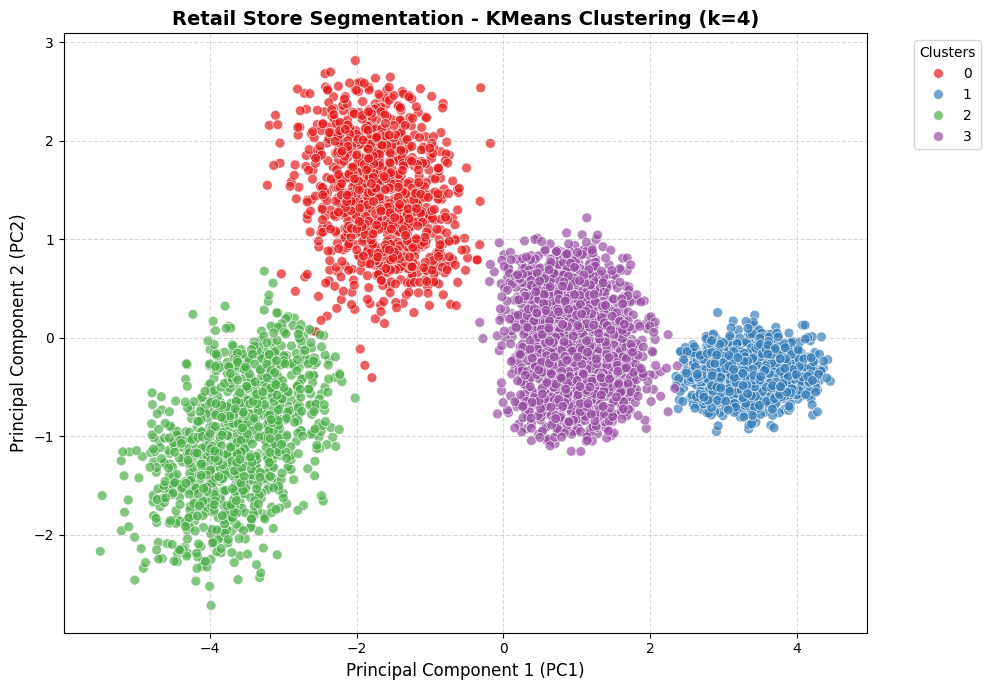

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =====================================================================
# 1. TRAIN THE FINAL K-MEANS MODEL
# =====================================================================
# Based on the elbow curve, let's select 4 clusters (adjust this if needed)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)

# Predict cluster assignments and add them back to your original DataFrame
df["Cluster"] = kmeans.fit_predict(X_scaled)

# View the distribution of retail stores per cluster
print("--- Store Count Per Cluster ---")
print(df["Cluster"].value_counts())
print("\n")

# =====================================================================
# 2. PROFILE THE CLUSTERS (Understand what each group represents)
# =====================================================================
print("--- Average Feature Values per Cluster ---")
cluster_profiles = df.groupby("Cluster").mean(numeric_only=True)
# Drop Store_ID from the profile view as its average is meaningless
if "Store_ID" in cluster_profiles.columns:
    cluster_profiles = cluster_profiles.drop(columns=["Store_ID"])
display(cluster_profiles)

# =====================================================================
# 3. DIMENSIONALITY REDUCTION USING PCA FOR SCATTER PLOT
# =====================================================================
# Reduce the standardized data (X_scaled) down to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a temporary DataFrame for plotting purposes
df_pca = pd.DataFrame(data=X_pca, columns=["PC1", "PC2"])
df_pca["Cluster"] = df["Cluster"]

# =====================================================================
# 4. GENERATE THE SCATTER PLOT
# =====================================================================
plt.figure(figsize=(10, 7))

# Scatter plot color-coded by cluster assignments
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=df_pca,
    palette="Set1",  # Gives distinct, vibrant colors to each cluster
    alpha=0.7,
    edgecolor="w",
    s=50,
)

plt.title(
    f"Retail Store Segmentation - KMeans Clustering (k={optimal_k})",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Principal Component 1 (PC1)", fontsize=12)
plt.ylabel("Principal Component 2 (PC2)", fontsize=12)
plt.legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()